# **DATA SET PREPARATION**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import glob
import os
import io

path = '/content/drive/MyDrive/Colab Notebooks/Sheryar/Training'


csv_files = glob.glob(os.path.join(path, "*.csv"))


data_dict = {}
target_cols = ['B1', 'B2', 'B3', 'B4']

for f in csv_files:
    df_name = os.path.splitext(os.path.basename(f))[0]
    print(f"Processing: {df_name}")

    try:
        with open(f, 'r') as file:
            lines = file.readlines()


        header_line = lines[7].lstrip(';').strip()

        data_lines = [line.strip() for line in lines[9:]]


        csv_content = "\n".join([header_line] + data_lines)


        df = pd.read_csv(io.StringIO(csv_content), sep=',', skipinitialspace=True)


        available_cols = [col for col in target_cols if col in df.columns]
        data_dict[df_name] = df[available_cols]

        print(f"  Successfully loaded {df_name} with shape: {data_dict[df_name].shape}")
        if not data_dict[df_name].empty:
             display(data_dict[df_name].head(2))
    except Exception as e:
        print(f"  Error processing {f}: {e}")

print(f"\nCreated {len(data_dict)} separate DataFrames.")

Processing: urban
  Successfully loaded urban with shape: (495553, 4)


,B1,B2,B3,B4
0,298,332,261,263
1,305,343,271,272


Processing: water
  Successfully loaded water with shape: (386814, 4)


,B1,B2,B3,B4
0,235,251,186,185
1,236,250,187,177


Processing: road
  Successfully loaded road with shape: (69203, 4)


...

Processing: tesstt
  Successfully loaded tesstt with shape: (0, 4)
Processing: cpf-253
  Successfully loaded cpf-253 with shape: (133030, 4)


,B1,B2,B3,B4
0,244,262,189,243
1,244,263,188,247


Processing: sl-284
  Successfully loaded sl-284 with shape: (232509, 4)


,B1,B2,B3,B4
0,247,261,188,257
1,251,266,191,263



Created 6 separate DataFrames.


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
from google.colab import files


all_dfs = []
MAX_PIXELS_PER_CLASS = 133000

print("Processing individual dataframes for pixel limit and class labeling...")
for class_name, df in data_dict.items():

    if len(df) > MAX_PIXELS_PER_CLASS:
        df_sampled = df.sample(n=MAX_PIXELS_PER_CLASS, random_state=42).copy()
        print(f"  Class '{class_name}' sampled from {len(df)} to {MAX_PIXELS_PER_CLASS} pixels.")
    else:
        df_sampled = df.copy()
        print(f"  Class '{class_name}' (size: {len(df)}) kept as is.")



    df_sampled['class'] = class_name
    all_dfs.append(df_sampled)
    print(len(all_dfs))


final_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nCombined final_df created with shape: {final_df.shape}")
print("First 5 rows of final_df with class labels (strings):")
display(final_df.head())
final_df.to_csv("Balanced_Dataset.csv", index=False)
files.download("Balanced_Dataset.csv")

bands_df = final_df[['B1', 'B2', 'B3', 'B4']].copy()

B = bands_df['B1']
G = bands_df['B2']
R = bands_df['B3']
NIR = bands_df['B4']

bands_df['GNDVI'] = (NIR - G) / (NIR + G + 1e-6)

bands_df['EVI'] = 2.5 * ((NIR - R) / (NIR + 6 * R - 7.5 * B + 1 + 1e-6))

bands_df['SAVI'] = ((NIR - R) * (1 + 0.5)) / (NIR + R + 0.5 + 1e-6)

engineered_df = bands_df

print(f"\nDataFrame after feature engineering: {engineered_df.shape}")
print("First 5 rows of engineered_df before normalization:")
display(engineered_df.head())


feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']

scaler = StandardScaler()

engineered_df[feature_cols] = scaler.fit_transform(engineered_df[feature_cols])

print(f"\nDataFrame after normalization: {engineered_df.shape}")
print("First 5 rows of engineered_df after normalization:")
display(engineered_df.head())

engineered_df['class'] = final_df['class']

label_encoder = LabelEncoder()
engineered_df['class'] = label_encoder.fit_transform(engineered_df['class'])

print(f"\nFinal DataFrame with engineered and normalized features and INTEGER class labels: {engineered_df.shape}")
print("First 5 rows of the final engineered DataFrame:")
display(engineered_df.head())
print(f"\nMapping of original class names to integer labels: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Processing individual dataframes for pixel limit and class labeling...
  Class 'urban' sampled from 495553 to 133000 pixels.
1
  Class 'water' sampled from 386814 to 133000 pixels.
2
  Class 'road' (size: 69203) kept as is.
3
  Class 'tesstt' (size: 0) kept as is.
4
  Class 'cpf-253' sampled from 133030 to 133000 pixels.
5
  Class 'sl-284' sampled from 232509 to 133000 pixels.
6

Combined final_df created with shape: (601203, 5)
First 5 rows of final_df with class labels (strings):


,B1,B2,B3,B4,class
0,295,328,256,250,urban
1,309,356,290,294,urban
2,272,297,231,229,urban
3,267,293,232,230,urban
4,286,323,260,261,urban


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DataFrame after feature engineering: (601203, 7)
First 5 rows of engineered_df before normalization:


...


DataFrame after normalization: (601203, 7)
First 5 rows of engineered_df after normalization:


,B1,B2,B3,B4,GNDVI,EVI,SAVI
0,1.789503,1.760431,1.705475,0.636244,-0.572182,0.816080,-0.777244
1,2.371835,2.634910,2.775345,1.836813,-0.029561,0.486165,-0.564209
2,0.832817,0.792257,0.918805,0.063245,-0.494409,0.706529,-0.691721
3,0.624841,0.667331,0.950272,0.090531,-0.373459,0.712986,-0.691507
4,1.415148,1.604274,1.831342,0.936386,-0.177408,0.615320,-0.620358



Final DataFrame with engineered and normalized features and INTEGER class labels: (601203, 8)
First 5 rows of the final engineered DataFrame:


,B1,B2,B3,B4,GNDVI,EVI,SAVI,class
0,1.789503,1.760431,1.705475,0.636244,-0.572182,0.816080,-0.777244,3
1,2.371835,2.634910,2.775345,1.836813,-0.029561,0.486165,-0.564209,3
2,0.832817,0.792257,0.918805,0.063245,-0.494409,0.706529,-0.691721,3
3,0.624841,0.667331,0.950272,0.090531,-0.373459,0.712986,-0.691507,3
4,1.415148,1.604274,1.831342,0.936386,-0.177408,0.615320,-0.620358,3



Mapping of original class names to integer labels: [('cpf-253', np.int64(0)), ('road', np.int64(1)), ('sl-284', np.int64(2)), ('urban', np.int64(3)), ('water', np.int64(4))]


## **Random Forest**


--- Model Hyperparameters ---
Random State: 42
Test Size: 0.2
Number of Estimators (n_estimators): 100
Maximum Depth (max_depth): 10
Minimum Samples Split (min_samples_split): 5
Minimum Samples Leaf (min_samples_leaf): 2
Maximum Features (max_features): sqrt
Number of Jobs (n_jobs): -1
-------------------------------

Training data shape: (480962, 7)
Test data shape: (120241, 7)

Training Random Forest Model...
Model training complete.


--- Overall Accuracy (OA) and Kappa Score ---


,Training Set,Test Set
Metric,,
Overall Accuracy,0.887022,0.884532
Kappa Score,0.857092,0.853943



=== Training Set Performance ===
Classification Report:
              precision    recall  f1-score   support

     cpf-253       0.79      0.88      0.83    106400
        road       0.87      0.84      0.85     55362
      sl-284       0.84      0.82      0.83    106400
       urban       0.96      0.93      0.94    106400
       water       0.99      0.94      0.97    106400

    accuracy                           0.89    480962
   macro avg       0.89      0.88      0.88    480962
weighted avg       0.89      0.89      0.89    480962


=== Test Set Performance ===
Classification Report:
              precision    recall  f1-score   support

     cpf-253       0.78      0.88      0.83     26600
        road       0.86      0.83      0.84     13841
      sl-284       0.84      0.82      0.83     26600
       urban       0.95      0.92      0.94     26600
       water       0.99      0.94      0.97     26600

    accuracy                           0.88    120241
   macro avg       0.

,Precision,Recall,F1-Score
Class,,,
cpf-253,0.785603,0.879662,0.829976
road,0.865817,0.835555,0.850417
sl-284,0.842390,0.824070,0.833129
urban,0.955182,0.927002,0.940881
water,0.994132,0.944135,0.968489



--- Per-class Performance (Test Set) ---


,Precision,Recall,F1-Score
Class,,,
cpf-253,0.784334,0.877481,0.828297
road,0.858949,0.829348,0.843889
sl-284,0.838245,0.822331,0.830212
urban,0.952892,0.923947,0.938197
water,0.994253,0.943083,0.967992


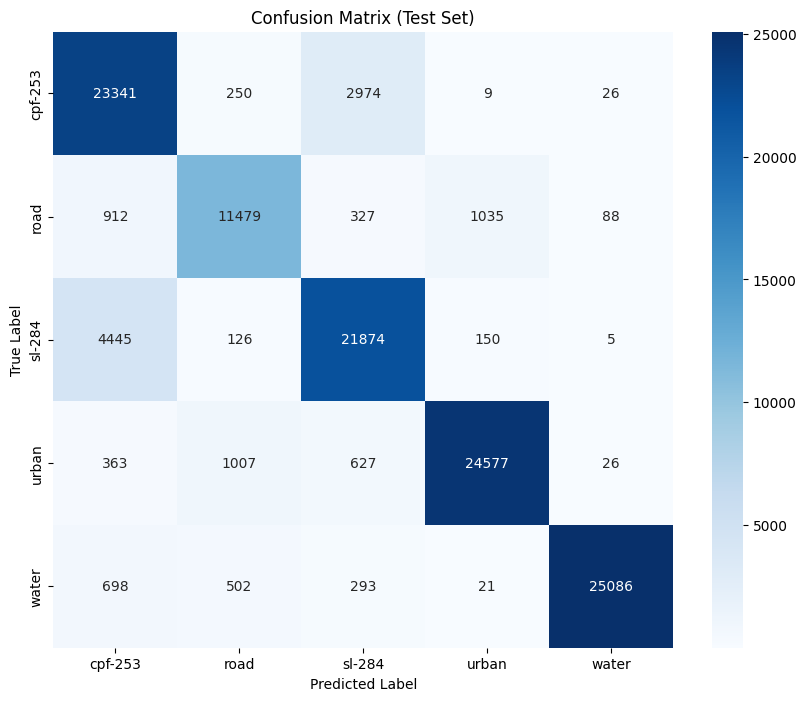

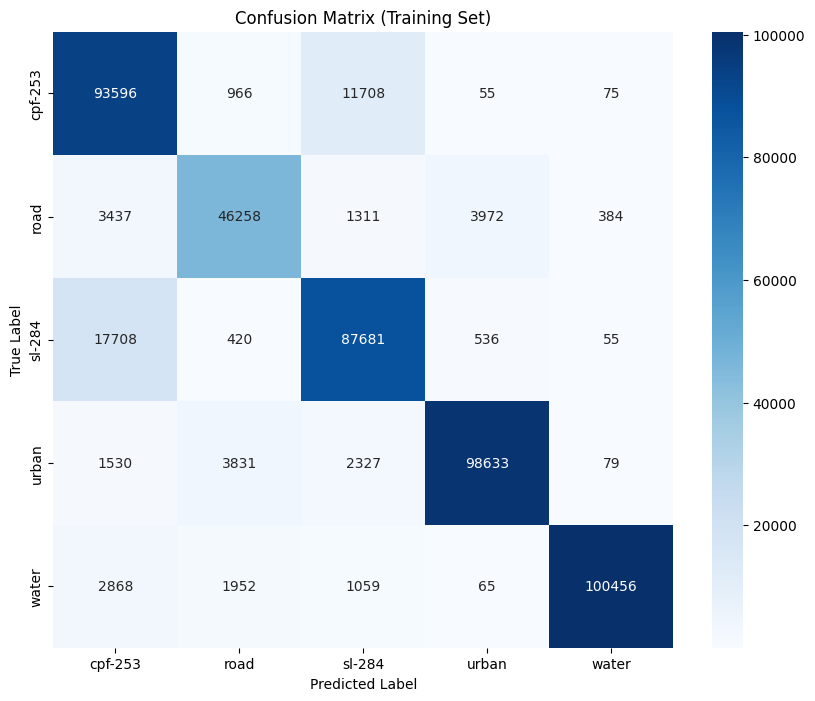

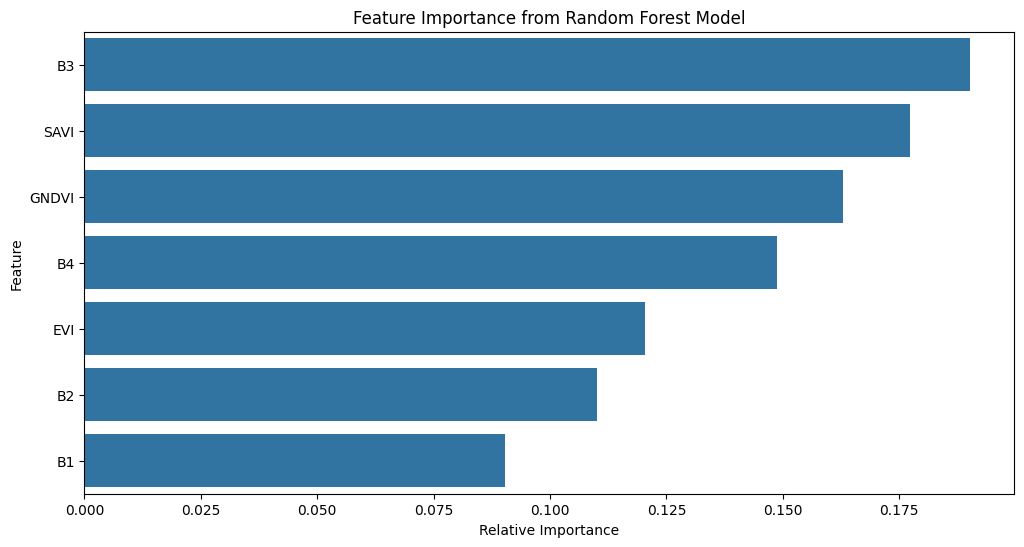


--- Feature Importances ---


,Feature,Importance
2,B3,0.190231
6,SAVI,0.177369
4,GNDVI,0.162935
3,B4,0.148799
5,EVI,0.120338
1,B2,0.110076
0,B1,0.090253


---------------------------



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, cohen_kappa_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_ESTIMATORS = 100
MAX_DEPTH = 10
MIN_SAMPLES_SPLIT = 5
MIN_SAMPLES_LEAF = 2
MAX_FEATURES = 'sqrt'
N_JOBS = -1


print("\n--- Model Hyperparameters ---")
hyperparams = {
    "Random State": RANDOM_STATE,
    "Test Size": TEST_SIZE,
    "Number of Estimators (n_estimators)": N_ESTIMATORS,
    "Maximum Depth (max_depth)": MAX_DEPTH,
    "Minimum Samples Split (min_samples_split)": MIN_SAMPLES_SPLIT,
    "Minimum Samples Leaf (min_samples_leaf)": MIN_SAMPLES_LEAF,
    "Maximum Features (max_features)": MAX_FEATURES,
    "Number of Jobs (n_jobs)": N_JOBS
}
for param, value in hyperparams.items():
    print(f"{param}: {value}")
print("-------------------------------\n")

feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']
X = engineered_df[feature_cols]
y = engineered_df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train_scaled = X_train
X_test_scaled = X_test

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}\n")


rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    max_features=MAX_FEATURES,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

print("Training Random Forest Model...")
rf_model.fit(X_train_scaled, y_train)
print("Model training complete.\n")

if 'label_encoder' in globals():
    target_names = label_encoder.classes_
else:
    target_names = [str(i) for i in sorted(y.unique())]
    print("Warning: label_encoder not found. Using numeric class names for evaluation.")


y_train_pred = rf_model.predict(X_train_scaled)

y_test_pred = rf_model.predict(X_test_scaled)

print("\n--- Overall Accuracy (OA) and Kappa Score ---")
oa_train = accuracy_score(y_train, y_train_pred)
oa_test = accuracy_score(y_test, y_test_pred)

kappa_train = cohen_kappa_score(y_train, y_train_pred)
kappa_test = cohen_kappa_score(y_test, y_test_pred)

accuracy_data = {
    "Metric": ["Overall Accuracy", "Kappa Score"],
    "Training Set": [oa_train, kappa_train],
    "Test Set": [oa_test, kappa_test]
}
accuracy_df = pd.DataFrame(accuracy_data).set_index("Metric")
display(accuracy_df)

print("\n=== Training Set Performance ===")
print("Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=target_names))

print("\n=== Test Set Performance ===")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

precision_train, recall_train, f1_train, _ = precision_recall_fscore_support(y_train, y_train_pred, labels=range(len(target_names)), average=None)
per_class_train_df = pd.DataFrame({
    'Class': target_names,
    'Precision': precision_train,
    'Recall': recall_train,
    'F1-Score': f1_train
}).set_index('Class')
print("\n--- Per-class Performance (Training Set) ---")
display(per_class_train_df)

precision_test, recall_test, f1_test, _ = precision_recall_fscore_support(y_test, y_test_pred, labels=range(len(target_names)), average=None)
per_class_test_df = pd.DataFrame({
    'Class': target_names,
    'Precision': precision_test,
    'Recall': recall_test,
    'F1-Score': f1_test
}).set_index('Class')
print("\n--- Per-class Performance (Test Set) ---")
display(per_class_test_df)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Training Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

if hasattr(rf_model, 'feature_importances_'):
    importances = rf_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title('Feature Importance from Random Forest Model')
    plt.xlabel('Relative Importance')
    plt.ylabel('Feature')
    plt.show()

    print("\n--- Feature Importances ---")
    display(feature_importance_df)
    print("---------------------------\n")

else:
    print("Feature importances are not available for this model.")

## **Remaining Discarded Pixels**

Shape of the remaining (validation) dataset: (715906, 5)

Class distribution in the remaining (validation) dataset:
class
urban      362553
water      253814
sl-284      99509
cpf-253        30
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



=== Performance on Remaining (Validation) Dataset ===
Overall Accuracy: 0.9142
Kappa Score: 0.8628
Classification Report:
              precision    recall  f1-score   support

     cpf-253       0.00      1.00      0.00        30
        road       0.00      0.00      0.00         0
      sl-284       0.88      0.77      0.82     99509
       urban       1.00      0.93      0.96    362553
       water       1.00      0.95      0.98    253814

    accuracy                           0.91    715906
   macro avg       0.57      0.73      0.55    715906
weighted avg       0.98      0.91      0.95    715906


--- Per-class Performance (Validation Set) ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

,Precision,Recall,F1-Score
Class,,,
cpf-253,0.000904,1.000000,0.001806
road,0.000000,0.000000,0.000000
sl-284,0.876210,0.770704,0.820077
urban,0.998818,0.925663,0.960850
water,0.998791,0.954041,0.975904


...

,Training Precision,Test Precision,Validation Precision
Class,,,
cpf-253,0.785603,0.784334,0.000904
road,0.865817,0.858949,0.000000
sl-284,0.842390,0.838245,0.876210
urban,0.955182,0.952892,0.998818
water,0.994132,0.994253,0.998791



--- Per-class Recall Comparison (Research Paper Table) ---


,Training Recall,Test Recall,Validation Recall
Class,,,
cpf-253,0.879662,0.877481,1.000000
road,0.835555,0.829348,0.000000
sl-284,0.824070,0.822331,0.770704
urban,0.927002,0.923947,0.925663
water,0.944135,0.943083,0.954041



--- Per-class F1-Score Comparison (Research Paper Table) ---


,Training F1-Score,Test F1-Score,Validation F1-Score
Class,,,
cpf-253,0.829976,0.828297,0.001806
road,0.850417,0.843889,0.000000
sl-284,0.833129,0.830212,0.820077
urban,0.940881,0.938197,0.960850
water,0.968489,0.967992,0.975904


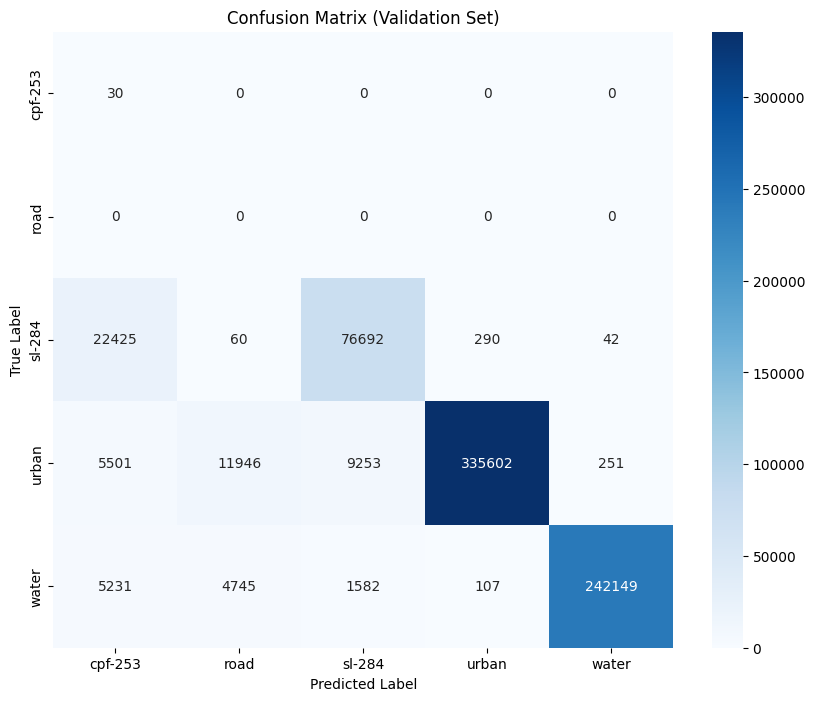


First 5 predictions on the remaining (validation) dataset:


,Actual,Predicted
0,water,water
1,water,water
2,water,water
3,water,water
4,water,water


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, cohen_kappa_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

truncated_names = ['water', 'urban', 'sl-284', 'cpf-253']

remaining_data_list = []

for name in truncated_names:
    if name in data_dict:
        original_df = data_dict[name]

        if len(original_df) > MAX_PIXELS_PER_CLASS:
            remaining_df = original_df.iloc[MAX_PIXELS_PER_CLASS:].copy()
            if not remaining_df.empty:

                remaining_df['class'] = label_encoder.transform([name])[0]
                remaining_data_list.append(remaining_df)

if not remaining_data_list:
    print("No remaining data found to evaluate.")
else:

    remaining_df_full = pd.concat(remaining_data_list, ignore_index=True)

    print(f"Shape of the remaining (validation) dataset: {remaining_df_full.shape}")
    print("\nClass distribution in the remaining (validation) dataset:")

    print(remaining_df_full['class'].map(lambda x: target_names[x]).value_counts())

    B_rem = remaining_df_full['B1']
    G_rem = remaining_df_full['B2']
    R_rem = remaining_df_full['B3']
    NIR_rem = remaining_df_full['B4']

    remaining_df_full['GNDVI'] = (NIR_rem - G_rem) / (NIR_rem + G_rem + 1e-6)
    remaining_df_full['EVI'] = 2.5 * ((NIR_rem - R_rem) / (NIR_rem + 6 * R_rem - 7.5 * B_rem + 1 + 1e-6))
    remaining_df_full['SAVI'] = ((NIR_rem - R_rem) * (1 + 0.5)) / (NIR_rem + R_rem + 0.5 + 1e-6)

    feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']
    X_remaining = remaining_df_full[feature_cols]
    y_remaining = remaining_df_full['class']

    X_remaining_scaled = scaler.transform(X_remaining)

    y_remaining_pred = rf_model.predict(X_remaining_scaled)

    print("\n=== Performance on Remaining (Validation) Dataset ===")

    oa_validation = accuracy_score(y_remaining, y_remaining_pred)
    kappa_validation = cohen_kappa_score(y_remaining, y_remaining_pred)

    print(f"Overall Accuracy: {oa_validation:.4f}")
    print(f"Kappa Score: {kappa_validation:.4f}")

    print("Classification Report:")
    print(classification_report(y_remaining, y_remaining_pred, target_names=target_names))

    precision_val, recall_val, f1_val, _ = precision_recall_fscore_support(y_remaining, y_remaining_pred, labels=range(len(target_names)), average=None)
    per_class_val_df = pd.DataFrame({
        'Class': target_names,
        'Precision': precision_val,
        'Recall': recall_val,
        'F1-Score': f1_val
    }).set_index('Class')
    print("\n--- Per-class Performance (Validation Set) ---")
    display(per_class_val_df)

    print("\n--- Overall Accuracy and Kappa Score Comparison (Research Paper Table) ---")
    comparison_accuracy_df = pd.DataFrame({
        "Metric": ["Overall Accuracy", "Kappa Score"],
        "Training Set": [oa_train, kappa_train],
        "Test Set": [oa_test, kappa_test],
        "Validation Set": [oa_validation, kappa_validation]
    }).set_index("Metric")
    display(comparison_accuracy_df)

    print("\n--- Per-class Precision Comparison (Research Paper Table) ---")
    precision_comparison_df = pd.DataFrame({
        'Class': target_names,
        'Training Precision': precision_train,
        'Test Precision': precision_test,
        'Validation Precision': precision_val
    }).set_index('Class')
    display(precision_comparison_df)

    print("\n--- Per-class Recall Comparison (Research Paper Table) ---")
    recall_comparison_df = pd.DataFrame({
        'Class': target_names,
        'Training Recall': recall_train,
        'Test Recall': recall_test,
        'Validation Recall': recall_val
    }).set_index('Class')
    display(recall_comparison_df)

    print("\n--- Per-class F1-Score Comparison (Research Paper Table) ---")
    f1_comparison_df = pd.DataFrame({
        'Class': target_names,
        'Training F1-Score': f1_train,
        'Test F1-Score': f1_test,
        'Validation F1-Score': f1_val
    }).set_index('Class')
    display(f1_comparison_df)
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_remaining, y_remaining_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix (Validation Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("\nFirst 5 predictions on the remaining (validation) dataset:")
    display(pd.DataFrame({'Actual': y_remaining.map(lambda x: target_names[x]), 'Predicted': pd.Series(y_remaining_pred).map(lambda x: target_names[x])}).head())



In [ ]:
training_misclassification_rate = 1 - oa_train
print(f"\nTraining Misclassification Rate: {training_misclassification_rate:.4f}")


Training Misclassification Rate: 0.1130
